In [1]:
import os
os.environ["PYTHONWARNING"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
import scanpy as sc
import numpy as np

In [4]:
sc.settings.set_figure_params(frameon=False, fontsize=10, vector_friendly=True)
sc.settings._vector_friendly = False
sc.settings.verbosity = 2

In [5]:
# set working directory
project_dir = os.path.expanduser("~/BreastCancerG0arrest/")
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# figure directory
figure_dir = working_dir + "figures/"
# data directory
data_dir = working_dir + "data/"

In [6]:
adata_full = sc.read_h5ad(data_dir + "adata_full_harmony_integration.h5ad")

In [7]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list("quiescence", ["#2FBF71", "#8C8C8C", "#6A5ACD"], N=256)

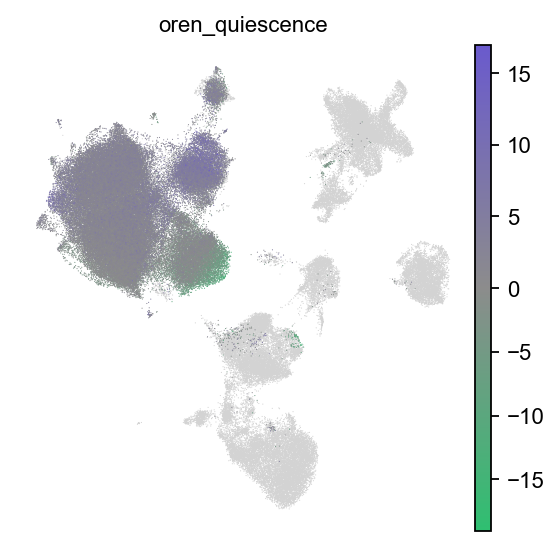

In [8]:
sc.pl.umap(adata_full, color="oren_quiescence", cmap=cmap, vcenter=0, size=1, save="_quiescence_score.pdf")

In [9]:
adata = adata_full[adata_full.obs["malignancy"] == "malignant"].copy()

In [10]:
adata.X = adata.layers["counts"].copy()
sc.pp.filter_genes(adata, min_cells=20)
sc.pp.normalize_total(adata, target_sum=1e4)
adata.X = np.log1p(adata.X)

filtered out 590 genes that are detected in less than 20 cells
normalizing counts per cell
    finished (0:00:01)


In [11]:
sc.tl.rank_genes_groups(
    adata, groupby="cycling_state_oren", method="wilcoxon", use_raw=False
)

ranking genes
    finished (0:05:08)


In [12]:
sc.tl.filter_rank_genes_groups(adata, min_in_group_fraction=0.25, max_out_group_fraction=0.5)

Filtering genes using: min_in_group_fraction: 0.25 min_fold_change: 1, max_out_group_fraction: 0.5


In [14]:
degs = sc.get.rank_genes_groups_df(adata, group=None, key="rank_genes_groups_filtered", pval_cutoff=0.05)
degs.to_csv(data_dir + "cycling_states_degs.csv", index=False)